<a href="https://colab.research.google.com/github/marianamq-a11y/Estatistica-mariana/blob/main/apresenta%C3%A7ao01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Apresentação 1

Lais Zanquettim Stocco Teixeira - 14586772

Mariana Lopes Marques -14596593

Nayara Penati - 15677365



##Análise Descritiva: Perfil Antropométrico e Composição Corporal

Fonte dos Dados: Repositório Público / Acompanhamento Nutricional e Antropométrico (dados_apresentação01.xlsx)


**Contextualização**

Este trabalho analisa uma amostra de 25 pacientes submetidos à avaliação antropométrica. O objetivo é examinar a distribuição do Índice de Massa Corporal (IMC), a relação entre IMC e o percentual de gordura corporal segundo o sexo, além dos níveis de atividade física e objetivos individuais de cada indivíduo.


Lais Zanquettim Stocco Teixeira - 14586772

Mariana Lopes Marques -14596593

Nayara Penati - 15677365

### Dicionário de Dados

| Variável | Tipo de Variável | Descrição |
| :--- | :--- | :--- |
| **ID Paciente** | Qualitativa Nominal | Código de identificação do indivíduo (1 a 25) |
| **Sexo** | Qualitativa Nominal | Gênero biológico (Masculino / Feminino) |
| **Idade (anos)** | Quantitativa Discreta | Idade em anos completos |
| **Altura (m)** | Quantitativa Contínua | Estatura em metros |
| **Peso (kg)** | Quantitativa Contínua | Massa corporal em quilogramas |
| **IMC** | Quantitativa Contínua | Índice de Massa Corporal (kg/m²) |
| **Classificação IMC** | Qualitativa Ordinal | Categoria do IMC (Peso normal, Sobrepeso, Obesidade) |
| **% Gordura Corporal** | Quantitativa Contínua | Percentual de gordura corporal |
| **Nível de Atividade** | Qualitativa Ordinal | Grau de atividade física praticada |
| **Objetivo** | Qualitativa Nominal | Meta do acompanhamento (Hipertrofia, Emagrecimento, etc.) |

**Interpretação Descritiva dos Achados**

* **Perfil Demográfico:** A amostra apresenta 68,0% de indivíduos do sexo masculino (17 pacientes) e 32,0% do sexo feminino (8 pacientes).
* **Distribuição do IMC:** Quase metade da amostra (48,0%) situa-se na faixa de Peso Normal. Contudo, 52,0% do grupo possui excesso de peso, divididos em Sobrepeso (28,0%) e Obesidade (24,0%).
* **Comportamento do IMC:** O histograma demonstra maior densidade de pacientes com IMC entre 22 e 25 kg/m². A média (26,02 kg/m²) e a mediana (25,00 kg/m²) indicam distribuição central equilibrada.
* **Composição Corporal e Dimorfismo:** O gráfico de dispersão confirma a tendência positiva entre o aumento do IMC e do % de Gordura Corporal. Observa-se que, para o mesmo valor de IMC, pacientes do sexo feminino apresentam valores percentuais de gordura superiores aos do sexo masculino.
* **Metas dos Pacientes:** A busca por Hipertrofia (32,0%) e Emagrecimento (28,0%) representa a prioridade da maioria dos avaliados.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
import pandas as pd

# Banco de dados
file_path = '/content/dados_apresentação01 (1).xlsx'

# Carregar o arquivo Excel em um DataFrame
df = pd.read_excel(file_path)

# 1. Tabela de Frequência para 'Classificação IMC'
freq_imc = df["Classificação IMC"].value_counts().reset_index()
freq_imc.columns = ["Classificação IMC", "Frequência Absoluta"]
freq_imc["Frequência Relativa (%)"] = (
    freq_imc["Frequência Absoluta"] / len(df)
) * 100

print("--- TABELA DE FREQUÊNCIA: CLASSIFICAÇÃO IMC ---")
display(freq_imc)

# 2. Resumo das Medidas Estatísticas Numéricas
num_cols = [
    "Idade (anos)",
    "Altura (m)",
    "Peso (kg)",
    "IMC",
    "% Gordura Corporal",
]

resumo = df[num_cols].describe().T
resumo["Mediana"] = df[num_cols].median()
resumo["IQR"] = df[num_cols].quantile(0.75) - df[num_cols].quantile(0.25)
resumo["Amplitude"] = resumo["max"] - resumo["min"]  # <-- LINHA ADICIONADA

# Organiza e renomeia as colunas
resumo_final = resumo[
    ["mean", "Mediana", "std", "min", "max", "Amplitude", "IQR"]
].rename(  # <-- "Amplitude" ADICIONADO AQUI
    columns={
        "mean": "Média",
        "std": "Desvio Padrão",
        "min": "Mínimo",
        "max": "Máximo",
        "Amplitude": "Amplitude Total",  # <-- ADICIONADO PARA CLAREZA
        "IQR": "Amplitude Interquartil",
    }
)

print("\n--- MEDIDAS DESCRITIVAS NUMÉRICAS ---")
display(resumo_final.round(2))

--- TABELA DE FREQUÊNCIA: CLASSIFICAÇÃO IMC ---


,Classificação IMC,Frequência Absoluta,Frequência Relativa (%)
0,Peso normal,12,48.0
1,Sobrepeso,7,28.0
2,Obesidade,6,24.0



--- MEDIDAS DESCRITIVAS NUMÉRICAS ---


,Média,Mediana,Desvio Padrão,Mínimo,Máximo,Amplitude Total,Amplitude Interquartil
Idade (anos),39.28,40.00,13.10,20.00,64.0,44.00,25.00
Altura (m),1.68,1.65,0.11,1.52,1.9,0.38,0.17
Peso (kg),73.26,72.50,14.87,48.10,108.0,59.90,19.30
IMC,26.02,25.00,4.89,19.00,34.9,15.90,6.70
% Gordura Corporal,27.52,27.40,7.16,16.60,46.6,30.00,8.90


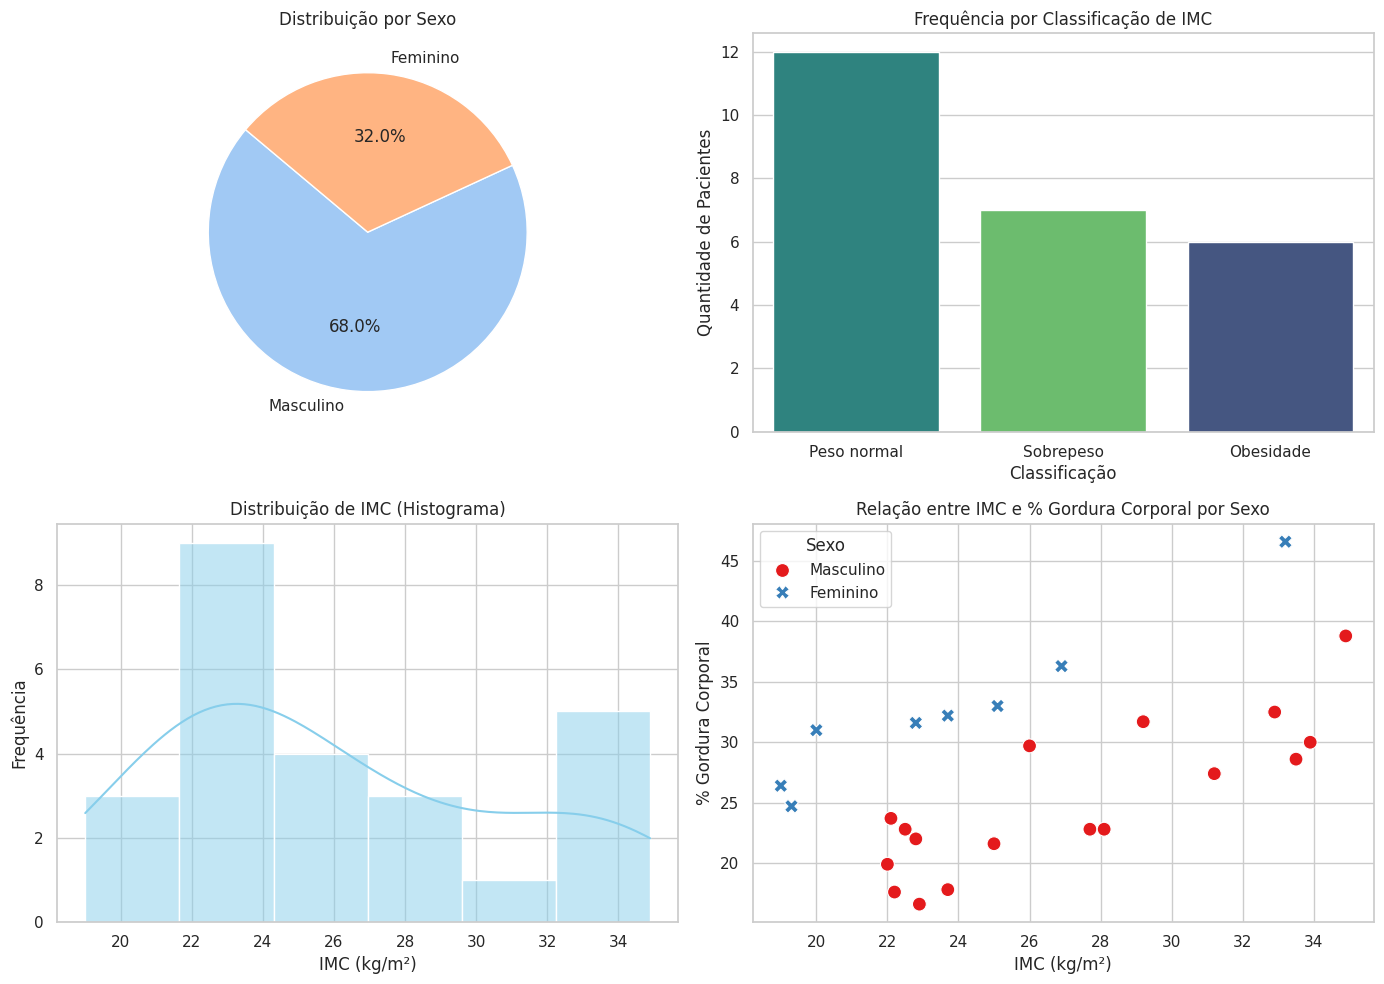

In [7]:
sns.set_theme(style="whitegrid")
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Gráfico de Pizza (Distribuição por Sexo)
sexo_counts = df["Sexo"].value_counts()
axes[0, 0].pie(
    sexo_counts,
    labels=sexo_counts.index,
    autopct="%1.1f%%",
    startangle=140,
    colors=sns.color_palette("pastel"),
)
axes[0, 0].set_title("Distribuição por Sexo")

# 2. Gráfico de Barras (Classificação IMC)
sns.countplot(
    data=df,
    x="Classificação IMC",
    hue="Classificação IMC",
    order=["Peso normal", "Sobrepeso", "Obesidade"],  # <-- LINHA ADICIONADA
    palette="viridis",
    ax=axes[0, 1],

)
axes[0, 1].set_title("Frequência por Classificação de IMC")
axes[0, 1].set_xlabel("Classificação")
axes[0, 1].set_ylabel("Quantidade de Pacientes")

# 3. Histograma (Distribuição de IMC)
sns.histplot(df["IMC"], kde=True, bins=6, color="skyblue", ax=axes[1, 0])
axes[1, 0].set_title("Distribuição de IMC (Histograma)")
axes[1, 0].set_xlabel("IMC (kg/m²)")
axes[1, 0].set_ylabel("Frequência")

# 4. Gráfico de Dispersão (IMC vs % Gordura Corporal por Sexo)
sns.scatterplot(
    data=df,
    x="IMC",
    y="% Gordura Corporal",
    hue="Sexo",
    style="Sexo",
    s=100,
    palette="Set1",
    ax=axes[1, 1],
)
axes[1, 1].set_title("Relação entre IMC e % Gordura Corporal por Sexo")
axes[1, 1].set_xlabel("IMC (kg/m²)")
axes[1, 1].set_ylabel("% Gordura Corporal")

plt.tight_layout()
plt.savefig("graficos_painel.png", dpi=300)
plt.show()

In [ ]:
plt.figure(figsize=(8, 5))
sns.boxplot(
    data=df,
    x="Nível de Atividade",
    y="Idade (anos)",
    palette="Set2",
    hue="Nível de Atividade",
)
plt.title("Boxplot: Idade por Nível de Atividade Física")
plt.show()

##Quartiz e Boxplot

Os quartis dividem um conjunto de dados ordenados em quatro partes iguais, enquanto o boxplot (gráfico de caixa) é a ferramenta visual que utiliza esses quartis para resumir a distribuição, a simetria e identificar outliers (valores discrepantes). Nesse gráfico, vamos observar esses conceitos na coluna de Índice de Massa Corporal.

Análise para a coluna 'IMC':

Mediana (Q2): 25.00
Primeiro Quartil (Q1): 22.50
Terceiro Quartil (Q3): 29.20
Distância Interquartil (IQR): 6.70


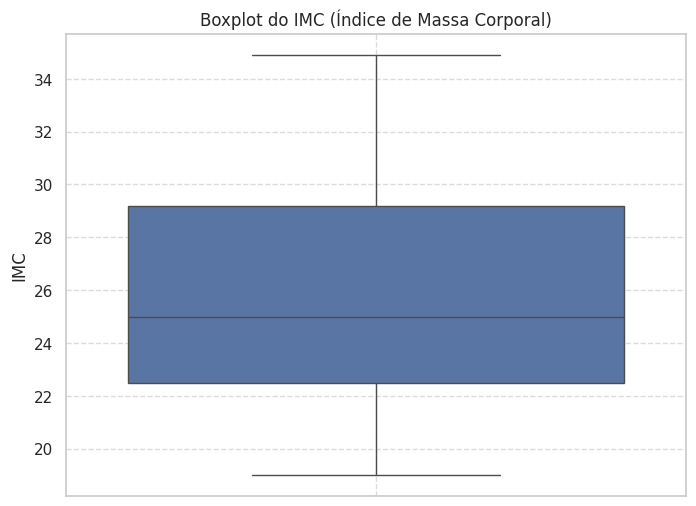

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Coluna numérica para análise
column_name = 'IMC'

# Verificar se a coluna existe e é numérica
if column_name in df.columns and pd.api.types.is_numeric_dtype(df[column_name]):
    # Calcular Mediana (Q2)
    median_value = df[column_name].median()

    # Calcular Quartis
    Q1 = df[column_name].quantile(0.25)
    Q3 = df[column_name].quantile(0.75)

    # Calcular Distância Interquartil (IQR)
    IQR = Q3 - Q1

    print(f"Análise para a coluna '{column_name}':\n")
    print(f"Mediana (Q2): {median_value:.2f}")
    print(f"Primeiro Quartil (Q1): {Q1:.2f}")
    print(f"Terceiro Quartil (Q3): {Q3:.2f}")
    print(f"Distância Interquartil (IQR): {IQR:.2f}")

    # Gerar Boxplot
    plt.figure(figsize=(8, 6))
    sns.boxplot(y=df[column_name])
    plt.title(f'Boxplot do {column_name} (Índice de Massa Corporal)')
    plt.ylabel(column_name)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.show()
else:
    print(f"A coluna '{column_name}' não foi encontrada ou não é numérica no DataFrame.")

##Gráfico de Dispersão: Correlação de Pearson
A correlação de Pearson ($r$) mede a força e a direção da associação linear entre duas variáveis contínuas, variando rigorosamente no intervalo de -1 a +1. Aqui, vamos ver a relação dos dados de Idade e a %Gordura Corporal por Sexo dos pacientes.

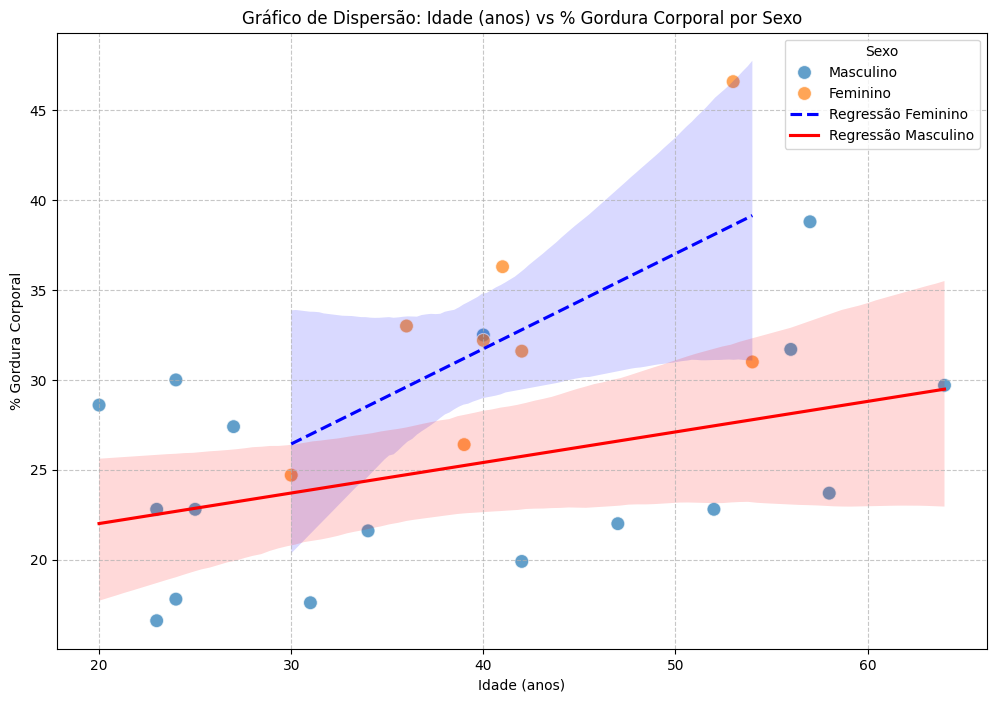

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

column1 = 'Idade (anos)'
column2 = '% Gordura Corporal'
categorical_column = 'Sexo'

if all(col in df.columns for col in [column1, column2, categorical_column]) and \
   pd.api.types.is_numeric_dtype(df[column1]) and pd.api.types.is_numeric_dtype(df[column2]):

    plt.figure(figsize=(12, 8))
    sns.scatterplot(x=column1, y=column2, hue=categorical_column, data=df, s=100, alpha=0.7)
    sns.regplot(x=column1, y=column2, data=df[df[categorical_column] == 'Feminino'], scatter=False, ax=plt.gca(), color='blue', line_kws={'linestyle':'--'}, label='Regressão Feminino')
    sns.regplot(x=column1, y=column2, data=df[df[categorical_column] == 'Masculino'], scatter=False, ax=plt.gca(), color='red', line_kws={'linestyle':'-'}, label='Regressão Masculino')

    plt.title(f'Gráfico de Dispersão: {column1} vs {column2} por {categorical_column}')
    plt.xlabel(column1)
    plt.ylabel(column2)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(title=categorical_column)
    plt.show()
else:
    print(f"Uma ou mais colunas ('{column1}', '{column2}', '{categorical_column}') não foram encontradas ou não são numéricas/categóricas conforme esperado no DataFrame.")

### Gráfico 1: Gráfico de Dispersão de Altura vs Peso

Este gráfico de dispersão mostra os pontos de dados individuais relacionando a altura (em metros) e o peso (em quilogramas) de cada paciente. Cada ponto representa um paciente, permitindo visualizar se existe uma correlação ou padrão entre essas duas variáveis.

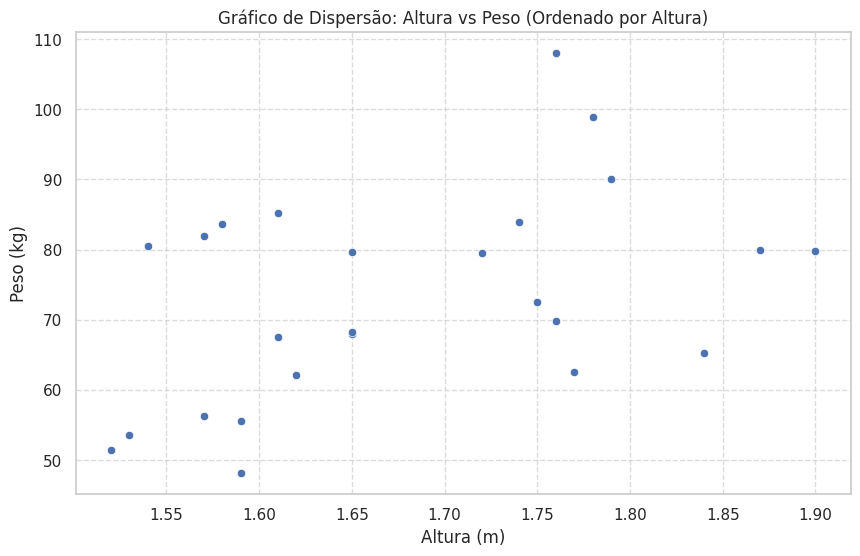

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Altura (m)', y='Peso (kg)', data=df.sort_values(by='Altura (m)'))
plt.title('Gráfico de Dispersão: Altura vs Peso (Ordenado por Altura)')
plt.xlabel('Altura (m)')
plt.ylabel('Peso (kg)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

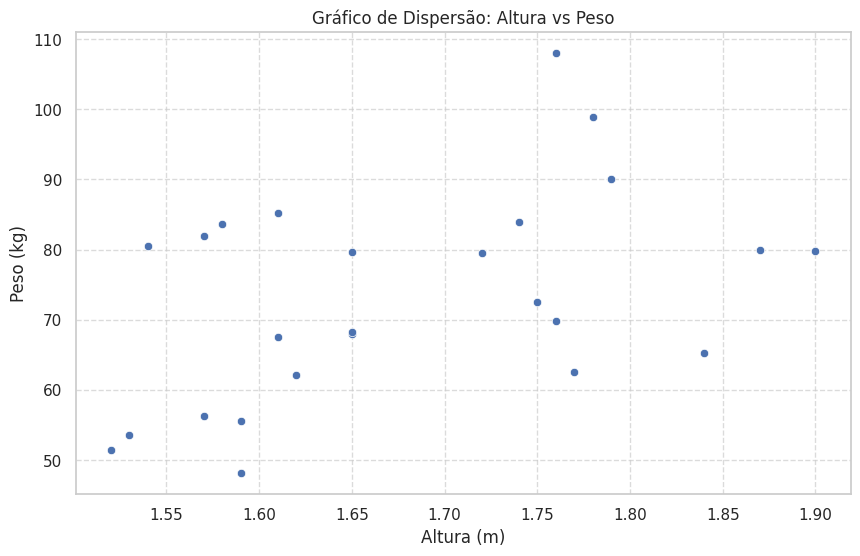

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.scatterplot(x='Altura (m)', y='Peso (kg)', data=df.sort_values(by='Altura (m)'))
plt.title('Gráfico de Dispersão: Altura vs Peso')
plt.xlabel('Altura (m)')
plt.ylabel('Peso (kg)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Gráfico 2: Gráfico de Dispersão com Regressão Linear de Altura vs Peso

Este gráfico de dispersão explora a relação entre a altura (em metros) e o peso (em quilogramas), incluindo uma linha de regressão linear. A linha de regressão ajuda a identificar a tendência geral e a força da correlação entre essas duas medidas, indicando como uma variável tende a mudar à medida que a outra varia.

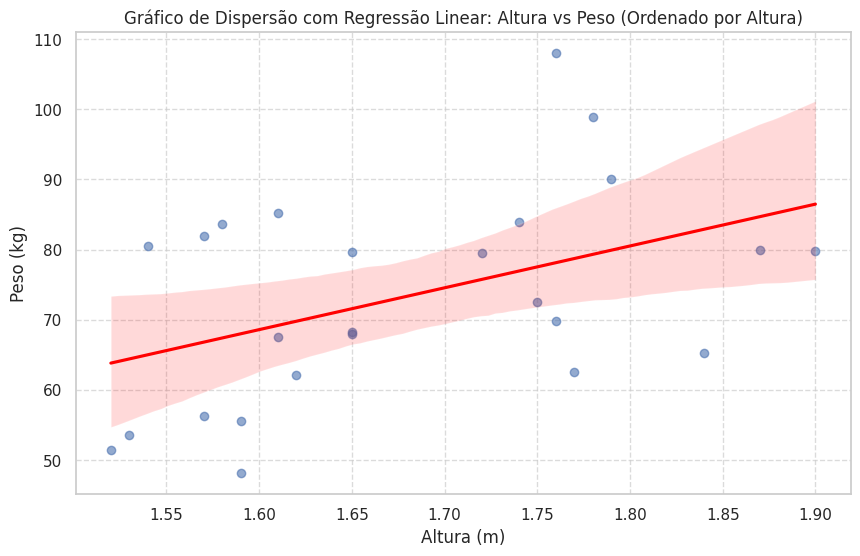

In [10]:
plt.figure(figsize=(10, 6))
sns.regplot(x='Altura (m)', y='Peso (kg)', data=df.sort_values(by='Altura (m)'), scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('Gráfico de Dispersão com Regressão Linear: Altura vs Peso (Ordenado por Altura)')
plt.xlabel('Altura (m)')
plt.ylabel('Peso (kg)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

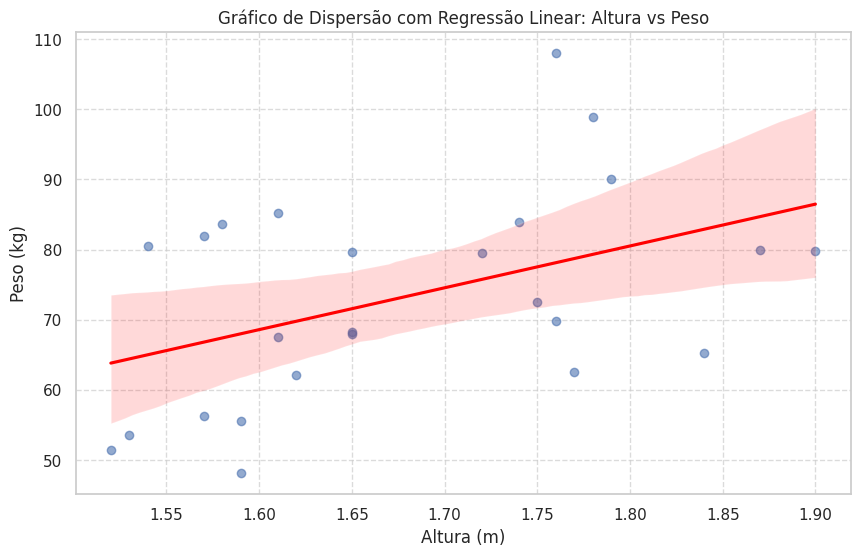

In [11]:
plt.figure(figsize=(10, 6))
sns.regplot(x='Altura (m)', y='Peso (kg)', data=df.sort_values(by='Altura (m)'), scatter_kws={'alpha':0.6}, line_kws={'color':'red'})
plt.title('Gráfico de Dispersão com Regressão Linear: Altura vs Peso')
plt.xlabel('Altura (m)')
plt.ylabel('Peso (kg)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

### Análise de Correlação Linear de Pearson

A Correlação de Pearson mede a força e a direção da relação linear entre duas variáveis contínuas. O coeficiente varia de -1 (correlação negativa perfeita) a +1 (correlação positiva perfeita), sendo 0 a ausência de correlação linear.

In [12]:
from scipy.stats import pearsonr

altura = df['Altura (m)']
peso = df['Peso (kg)']

correlation, _ = pearsonr(altura, peso)
print(f"O Coeficiente de Correlação de Pearson entre Altura e Peso é: {correlation:.2f}")

O Coeficiente de Correlação de Pearson entre Altura e Peso é: 0.45


### Análise de Regressão Linear Simples

A Regressão Linear Simples busca modelar a relação entre duas variáveis (uma dependente e uma independente) ajustando uma linha reta aos dados. Ela nos permite entender como a variável dependente (Peso) muda em resposta a uma mudança na variável independente (Altura), e também prever valores.

In [13]:
from scipy.stats import linregress

# Realizando a regressão linear
slope, intercept, r_value, p_value, std_err = linregress(altura, peso)

print(f"Equação da linha de regressão: Peso = {slope:.2f} * Altura + {intercept:.2f}")
print(f"Coeficiente de Determinação (R-quadrado): {r_value**2:.2f}")
print(f"Valor-p: {p_value:.3f}")
print(f"Erro padrão do coeficiente: {std_err:.2f}")

Equação da linha de regressão: Peso = 59.66 * Altura + -26.87
Coeficiente de Determinação (R-quadrado): 0.20
Valor-p: 0.025
Erro padrão do coeficiente: 24.92


### Gráfico 3: Gráfico de Dispersão de Idade vs IMC

Este último gráfico de dispersão visualiza a relação entre a idade (em anos) e o Índice de Massa Corporal (IMC) dos pacientes. Ele nos permite observar se há alguma tendência de mudança no IMC com o aumento ou diminuição da idade na sua amostra de dados.

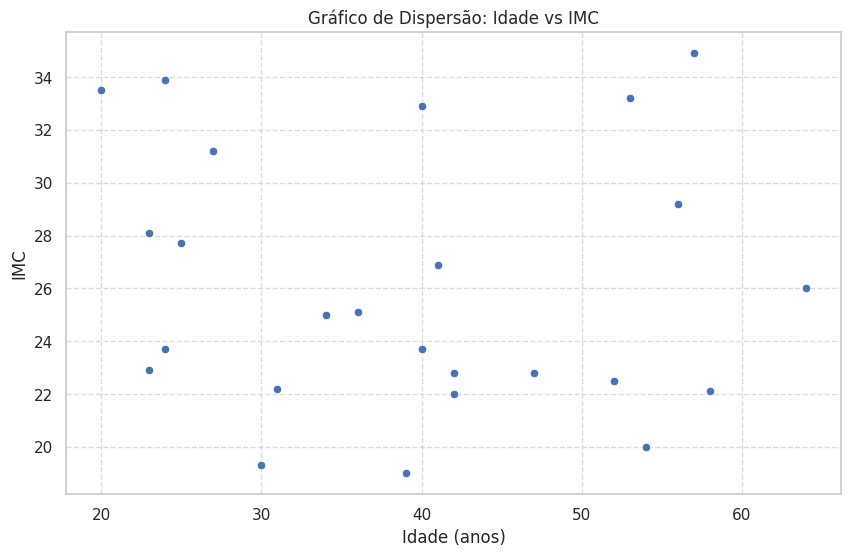

In [14]:
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Idade (anos)', y='IMC', data=df)
plt.title('Gráfico de Dispersão: Idade vs IMC')
plt.xlabel('Idade (anos)')
plt.ylabel('IMC')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()